# Titanic Model Comparison

This notebook compares multiple machine learning models for predicting passenger survival.

The models included are:
- Logistic Regression
- Random Forest
- Gradient Boosting

The goal is to compare their predictive accuracy and identify a stronger model than the baseline.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.load_data import load_data
from src.preprocess import select_features
from src.train import split_data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

## Load Dataset

We first load the Titanic dataset.

In [4]:
df = load_data()
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Prepare Features and Target

We select the baseline features and define the target variable.

In [5]:
features, target = select_features(df)
features.head()

,pclass,sex,age
0,3,0,22.0
1,1,1,38.0
2,3,1,26.0
3,1,1,35.0
4,3,0,35.0


## Train-Test Split

The dataset is split into training and testing subsets.

In [6]:
X_train, X_test, y_train, y_test = split_data(features, target)

## Define Models

Here we define the machine learning models that will be compared.

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

## Train and Evaluate Models

Each model is trained on the training data and evaluated on the test data using accuracy.

In [8]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

results

{'Logistic Regression': 0.8100558659217877,
 'Random Forest': 0.7932960893854749,
 'Gradient Boosting': 0.8100558659217877}

## Comparison Table

This table summarizes the accuracy scores for all tested models.

In [9]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df

,Model,Accuracy
0,Logistic Regression,0.810056
1,Random Forest,0.793296
2,Gradient Boosting,0.810056


## Model Comparison Chart

This visualization compares the accuracy of different models.

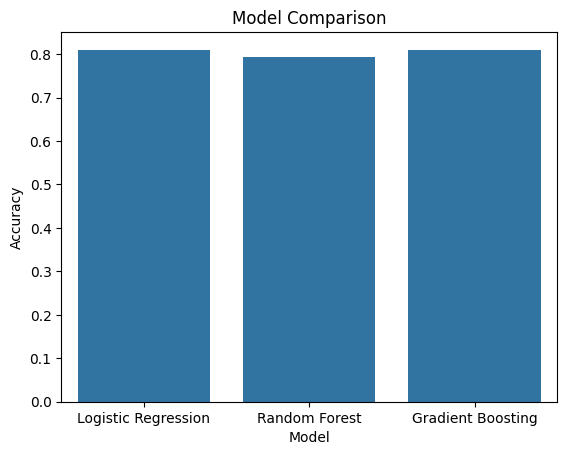

In [10]:
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Comparison")
plt.show()

## Model Comparison Summary

This comparison helps identify whether more advanced models outperform the baseline Logistic Regression model.

The best-performing model can be selected for further improvement and tuning.

## Confusion Matrix

A confusion matrix provides a more detailed view of classification performance by showing:

- true positives
- true negatives
- false positives
- false negatives

This helps us understand where the model makes mistakes.

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [12]:
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model_name

'Logistic Regression'

In [13]:
best_model = models[best_model_name]
best_preds = best_model.predict(X_test)

In [14]:
cm = confusion_matrix(y_test, best_preds)
cm

array([[91, 14],
       [20, 54]])

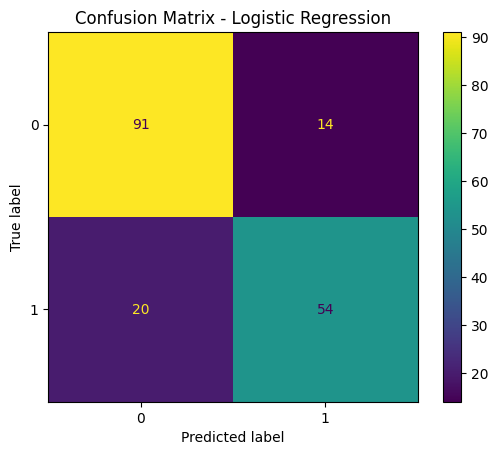

In [15]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Classification Report

The classification report provides detailed evaluation metrics including:

- precision
- recall
- f1-score

These metrics give a more complete understanding of model performance beyond accuracy.

In [16]:
from sklearn.metrics import classification_report

In [17]:
print(classification_report(y_test, best_preds))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Final Observation

Based on the comparison results, the best-performing model was selected and evaluated in more detail using a confusion matrix and classification report.

This provides a stronger understanding of model performance than accuracy alone.